In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
from pathlib import Path

print(Path.cwd())

c:\Users\Sreoshi\anomaly-detection\notebooks


In [55]:
#Why skiprows=1? We're telling Pandas to ignore the first metadata row and use the second row as the column header.

from pathlib import Path

data_path = Path("../data/raw/abohar_weather.csv")

print(data_path.resolve())
print(data_path.exists())

df = pd.read_csv(data_path, skiprows=2)

df.head()

C:\Users\Sreoshi\anomaly-detection\data\raw\abohar_weather.csv
True


,time,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01T00:00,3.0,96,1021.5
1,2020-01-01T01:00,2.5,97,1021.0
2,2020-01-01T02:00,1.9,98,1021.0
3,2020-01-01T03:00,1.7,98,1021.1
4,2020-01-01T04:00,1.5,99,1021.1


In [56]:
df = df.rename(columns={
    "time": "timestamp",
    "temperature_2m": "temperature",
    "relative_humidity_2m": "humidity",
    "pressure_msl": "pressure"
})

df.head()

,timestamp,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
0,2020-01-01T00:00,3.0,96,1021.5
1,2020-01-01T01:00,2.5,97,1021.0
2,2020-01-01T02:00,1.9,98,1021.0
3,2020-01-01T03:00,1.7,98,1021.1
4,2020-01-01T04:00,1.5,99,1021.1


In [57]:
df.shape


(43848, 4)

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43848 entries, 0 to 43847
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 43848 non-null  str    
 1   temperature_2m (°C)       43848 non-null  float64
 2   relative_humidity_2m (%)  43848 non-null  int64  
 3   pressure_msl (hPa)        43848 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 1.3 MB


In [59]:
# We want to know whether any sensor readings are missing.
df.isnull().sum()

timestamp                   0
temperature_2m (°C)         0
relative_humidity_2m (%)    0
pressure_msl (hPa)          0
dtype: int64

In [60]:
df.describe()  #Basic stats

,temperature_2m (°C),relative_humidity_2m (%),pressure_msl (hPa)
count,43848.000000,43848.000000,43848.000000
mean,24.716366,58.486430,1008.306735
std,8.793384,22.909271,7.647973
min,1.500000,5.000000,989.200000
25%,18.000000,41.000000,1001.900000
50%,26.400000,60.000000,1008.000000
75%,31.300000,77.000000,1015.000000
max,47.300000,100.000000,1027.200000


In [61]:
print("Start:", df["timestamp"].min())
print("End:", df["timestamp"].max())

Start: 2020-01-01T00:00
End: 2024-12-31T23:00


In [62]:
df["timestamp"].duplicated().sum()    # Duplicate timestamps? 0 means no duplicates, which is good.

np.int64(0)

In [63]:
# Check the sampling interval, this is important for timeseries data.
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].diff().value_counts().head()  

timestamp
0 days 01:00:00    43847
Name: count, dtype: int64

In [64]:
df = df.rename(columns={
    "temperature_2m (°C)": "temperature",
    "relative_humidity_2m (%)": "humidity",
    "pressure_msl (hPa)": "pressure"
})

df.columns

Index(['timestamp', 'temperature', 'humidity', 'pressure'], dtype='str')

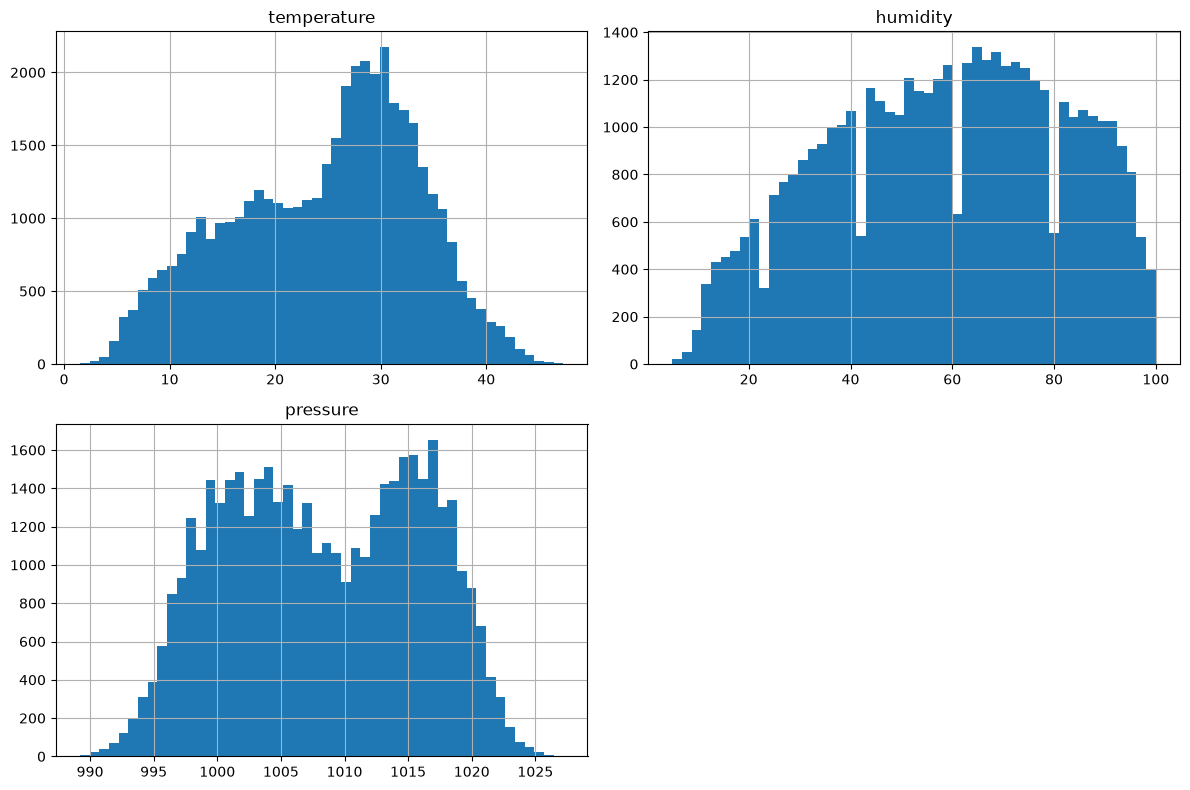

In [65]:
df[["temperature", "humidity", "pressure"]].hist(
    bins=50,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

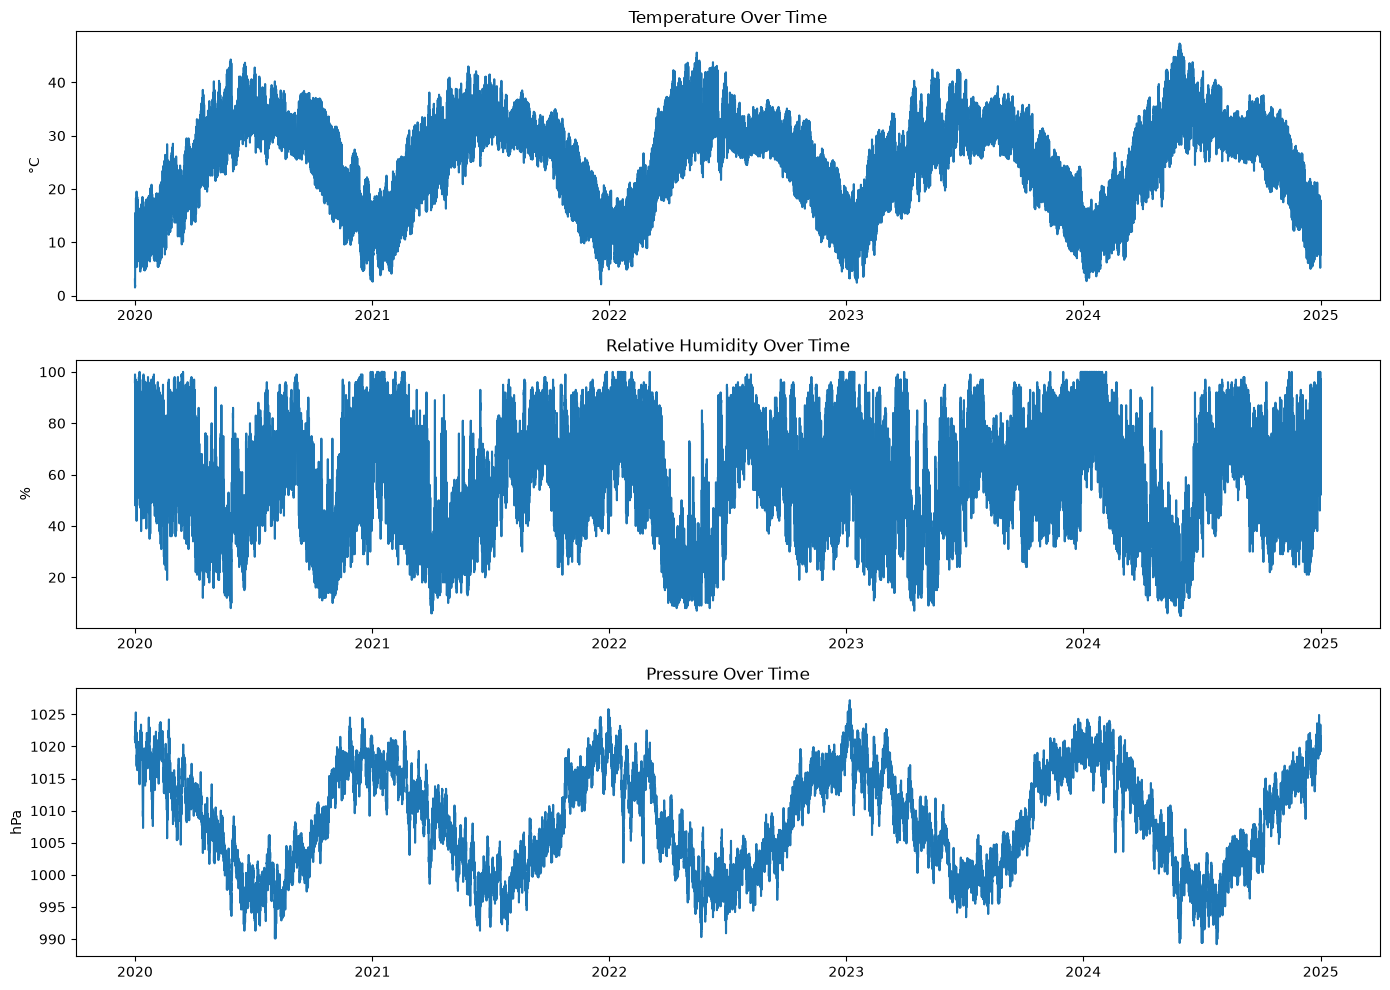

In [66]:
# Actual sensor distributions, We are going to look at the actual time series before deciding what an anomaly looks like.

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(df["timestamp"], df["temperature"])
axes[0].set_title("Temperature Over Time")
axes[0].set_ylabel("°C")

axes[1].plot(df["timestamp"], df["humidity"])
axes[1].set_title("Relative Humidity Over Time")
axes[1].set_ylabel("%")

axes[2].plot(df["timestamp"], df["pressure"])
axes[2].set_title("Pressure Over Time")
axes[2].set_ylabel("hPa")

plt.tight_layout()
plt.show()

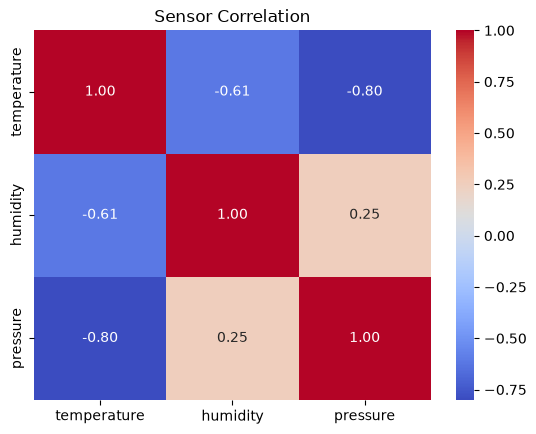

In [67]:
corr = df[["temperature", "humidity", "pressure"]].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Sensor Correlation")
plt.show()

In [68]:
df["hour"] = df["timestamp"].dt.hour
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["year"] = df["timestamp"].dt.year

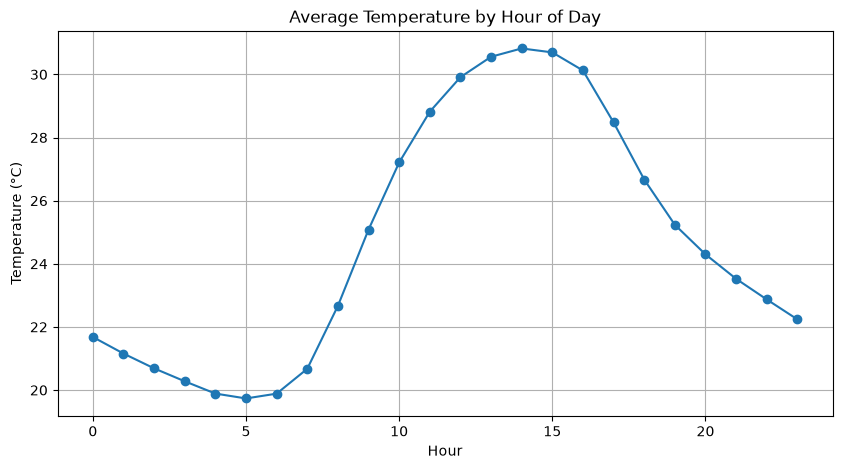

In [69]:
hourly_temp = df.groupby("hour")["temperature"].mean()

hourly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Temperature (°C)")
plt.grid()
plt.show()

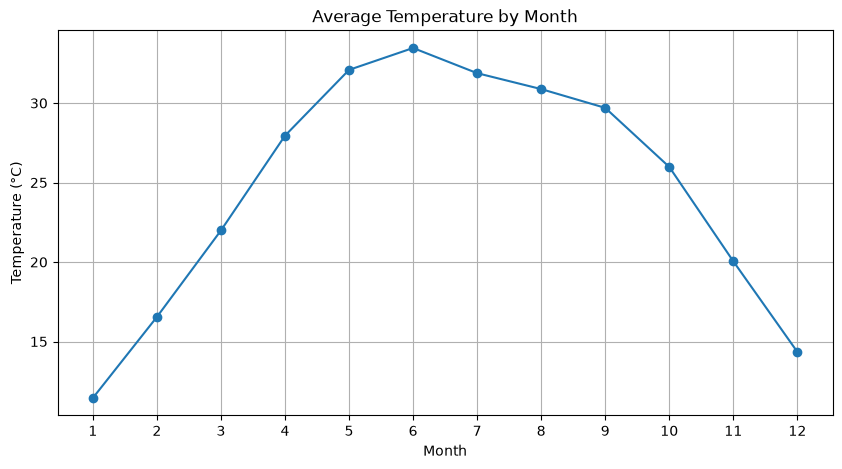

In [70]:
monthly_temp = df.groupby("month")["temperature"].mean()

monthly_temp.plot(figsize=(10, 5), marker="o")

plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [71]:
df[["temperature", "humidity", "pressure"]].corr()

,temperature,humidity,pressure
temperature,1.000000,-0.611447,-0.800485
humidity,-0.611447,1.000000,0.254298
pressure,-0.800485,0.254298,1.000000


In [72]:
df = df.sort_values("timestamp").reset_index(drop=True)     # Sort by timestamp and reset index for time series analysis

In [73]:
df["temperature_change"] = df["temperature"].diff()         #Sensor readings can be noisy, so we can look at the change in readings to identify anomalies.
df["humidity_change"] = df["humidity"].diff()
df["pressure_change"] = df["pressure"].diff()

In [74]:
df["temperature_rolling_mean"] = (                         # Rolling mean can help smooth out short term fluctuations and highlight longer term trends or cycles.
    df["temperature"].rolling(24).mean()
)

df["temperature_rolling_std"] = (
    df["temperature"].rolling(24).std()
)

In [75]:
# Why 24? because our data is hourly: 1 day = 24 observations
# So we ae asking: How unusual is this reading compared with the recent 24h behavior?

df["humidity_rolling_mean"] = (
    df["humidity"].rolling(24).mean()
)

df["humidity_rolling_std"] = (
    df["humidity"].rolling(24).std()
)

df["pressure_rolling_mean"] = (
    df["pressure"].rolling(24).mean()
)

df["pressure_rolling_std"] = (
    df["pressure"].rolling(24).std()
)

In [76]:
#Local deviation from the rolling mean can help identify anomalies that are not just outliers but also unusual compared to recent trends.
df["temperature_deviation"] = (                               
    df["temperature"] - df["temperature_rolling_mean"]
)

df["humidity_deviation"] = (
    df["humidity"] - df["humidity_rolling_mean"]
)

df["pressure_deviation"] = (
    df["pressure"] - df["pressure_rolling_mean"]
)

In [77]:
# notice that the first ~23 rows have NaN values for the rolling features. That's expected. We don't have 24 previous observations for the beginning of the dataset.

df.head(30)

,timestamp,temperature,humidity,pressure,hour,day,month,year,temperature_change,humidity_change,pressure_change,temperature_rolling_mean,temperature_rolling_std,humidity_rolling_mean,humidity_rolling_std,pressure_rolling_mean,pressure_rolling_std,temperature_deviation,humidity_deviation,pressure_deviation
0,2020-01-01 00:00:00,3.0,96,1021.5,0,1,1,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,2.5,97,1021.0,1,1,1,2020,-0.5,1.0,-0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2020-01-01 02:00:00,1.9,98,1021.0,2,1,1,2020,-0.6,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2020-01-01 03:00:00,1.7,98,1021.1,3,1,1,2020,-0.2,0.0,0.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2020-01-01 04:00:00,1.5,99,1021.1,4,1,1,2020,-0.2,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2020-01-01 05:00:00,2.0,98,1021.4,5,1,1,2020,0.5,-1.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2020-01-01 06:00:00,1.9,98,1021.7,6,1,1,2020,-0.1,0.0,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2020-01-01 07:00:00,1.7,98,1022.2,7,1,1,2020,-0.2,0.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2020-01-01 08:00:00,3.6,94,1022.7,8,1,1,2020,1.9,-4.0,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2020-01-01 09:00:00,6.6,85,1023.3,9,1,1,2020,3.0,-9.0,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
df.isnull().sum()  # see the  missing values in the rolling columns. Not filling them yet. We will handle that properly when we prepare the ML dataset.

timestamp                    0
temperature                  0
humidity                     0
pressure                     0
hour                         0
day                          0
month                        0
year                         0
temperature_change           1
humidity_change              1
pressure_change              1
temperature_rolling_mean    23
temperature_rolling_std     23
humidity_rolling_mean       23
humidity_rolling_std        23
pressure_rolling_mean       23
pressure_rolling_std        23
temperature_deviation       23
humidity_deviation          23
pressure_deviation          23
dtype: int64

In [79]:
#z-score normalization is a common technique to standardize features by removing the mean and scaling to unit variance. This is particularly useful for anomaly detection, as it allows us to identify outliers based on how many standard deviations away they are from the mean.

from scipy.stats import zscore

df["temperature_z"] = zscore(df["temperature"])
df["humidity_z"] = zscore(df["humidity"])
df["pressure_z"] = zscore(df["pressure"])

In [80]:
#checking the z-score values for the first few rows
df["zscore_anomaly"] = (
    (df["temperature_z"].abs() > 3) |
    (df["humidity_z"].abs() > 3) |
    (df["pressure_z"].abs() > 3)
)

In [81]:
df["zscore_anomaly"].value_counts()

zscore_anomaly
False    43848
Name: count, dtype: int64

In [82]:
df[df["zscore_anomaly"]][
    ["timestamp", "temperature", "humidity", "pressure",
     "temperature_z", "humidity_z", "pressure_z"]
].head(20)

,timestamp,temperature,humidity,pressure,temperature_z,humidity_z,pressure_z


In [83]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return lower, upper

In [84]:
temp_lower, temp_upper = iqr_bounds(df["temperature"])
hum_lower, hum_upper = iqr_bounds(df["humidity"])
pressure_lower, pressure_upper = iqr_bounds(df["pressure"])

print("Temperature:", temp_lower, "to", temp_upper)
print("Humidity:", hum_lower, "to", hum_upper)
print("Pressure:", pressure_lower, "to", pressure_upper)

Temperature: -1.9500000000000028 to 51.25
Humidity: -13.0 to 131.0
Pressure: 982.25 to 1034.65


In [85]:
# checking the IQR bounds for the first few rows
df["iqr_anomaly"] = (
    (df["temperature"] < temp_lower) |
    (df["temperature"] > temp_upper) |
    (df["humidity"] < hum_lower) |
    (df["humidity"] > hum_upper) |
    (df["pressure"] < pressure_lower) |
    (df["pressure"] > pressure_upper)
)

In [86]:
df["iqr_anomaly"].value_counts()

iqr_anomaly
False    43848
Name: count, dtype: int64

In [87]:
print("Z-score anomalies:", df["zscore_anomaly"].sum())   # compare the two baselines
print("IQR anomalies:", df["iqr_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0


In [88]:
pd.crosstab(                      # tells us how many anomalies were detected by both methods, and how many were unique to each method.
    df["zscore_anomaly"],
    df["iqr_anomaly"]
)

iqr_anomaly,False
zscore_anomaly,
False,43848


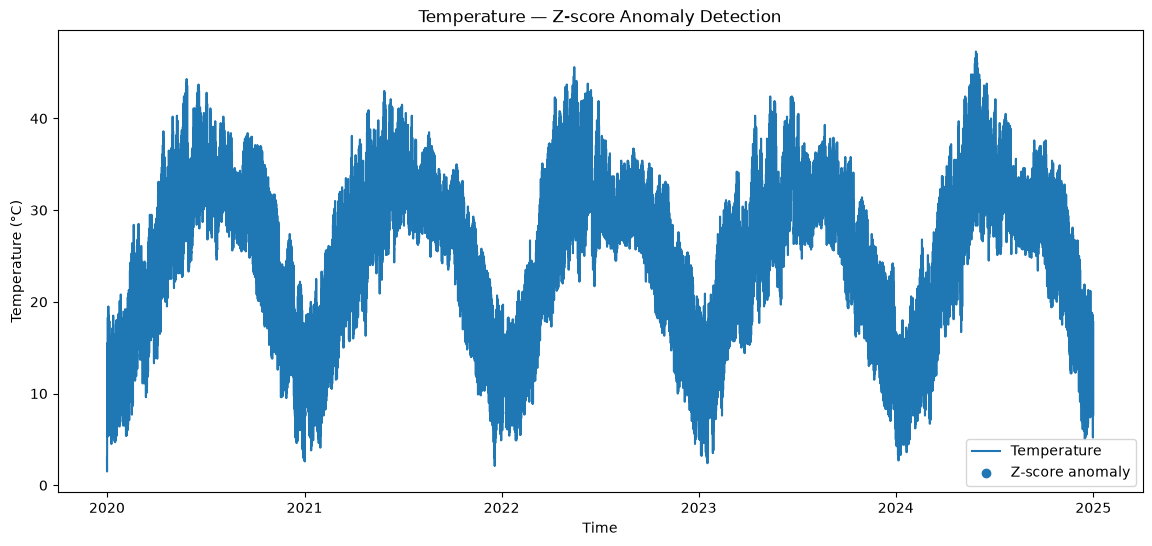

In [89]:
plt.figure(figsize=(14, 6))        # visualizing the anomalies detected by the z-score method. This helps us understand how the anomalies are distributed over time and how they relate to the actual temperature readings.

plt.plot(
    df["timestamp"],
    df["temperature"],
    label="Temperature"
)

anomalies = df[df["zscore_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Z-score anomaly"
)

plt.title("Temperature — Z-score Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

In [90]:
features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

In [91]:
ml_df = df.dropna(subset=features).copy()          # remove rows with NaN values in the features we will use for ML. This is important because many ML algorithms cannot handle NaN values.

In [92]:
print("Original rows:", len(df))
print("ML rows:", len(ml_df))

Original rows: 43848
ML rows: 43825


In [93]:
from sklearn.ensemble import IsolationForest

print("Isolation Forest is ready!")

Isolation Forest is ready!


In [94]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

In [95]:
X = ml_df[features]

print("Feature data shape:", X.shape)
display(X.head())

Feature data shape: (43825, 17)


,temperature,humidity,pressure,hour,month,temperature_change,humidity_change,pressure_change,temperature_rolling_mean,temperature_rolling_std,humidity_rolling_mean,humidity_rolling_std,pressure_rolling_mean,pressure_rolling_std,temperature_deviation,humidity_deviation,pressure_deviation
23,7.1,92,1023.2,23,1,-0.2,0.0,-0.2,7.520833,4.904477,82.000000,17.817920,1022.112500,1.030961,-0.420833,10.000000,1.087500
24,6.9,93,1022.7,0,1,-0.2,1.0,-0.5,7.683333,4.811912,81.875000,17.725718,1022.162500,1.029061,-0.783333,11.125000,0.537500
25,6.5,94,1022.6,1,1,-0.4,1.0,-0.1,7.850000,4.692362,81.750000,17.624711,1022.229167,1.001946,-1.350000,12.250000,0.370833
26,5.7,95,1022.6,2,1,-0.8,1.0,0.0,8.008333,4.544650,81.625000,17.514745,1022.295833,0.969302,-2.308333,13.375000,0.304167
27,5.3,96,1022.3,3,1,-0.4,1.0,-0.3,8.158333,4.383955,81.541667,17.438037,1022.345833,0.935288,-2.858333,14.458333,-0.045833


In [96]:
ml_df["isolation_prediction"] = model.fit_predict(X)

ml_df["isolation_anomaly"] = (
    ml_df["isolation_prediction"] == -1
)

In [97]:
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Isolation Forest anomalies: 5522


In [98]:
print(ml_df["isolation_anomaly"].value_counts())

isolation_anomaly
False    38303
True      5522
Name: count, dtype: int64


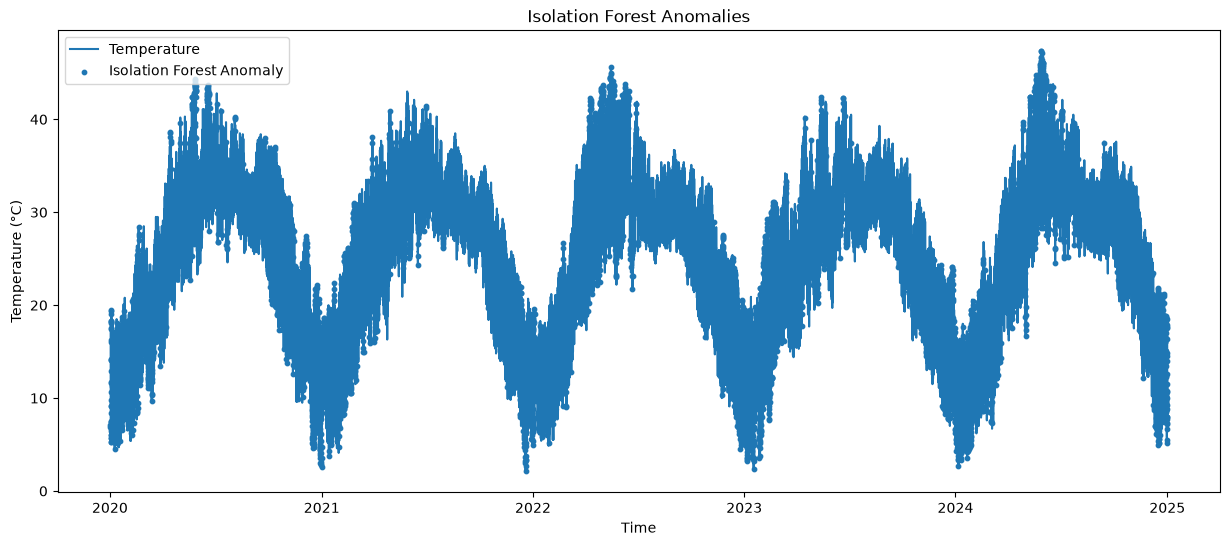

In [99]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["temperature"],
    label="Temperature"
)

anomalies = ml_df[ml_df["isolation_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Isolation Forest Anomaly",
    s=10
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.show()

In [100]:
ml_df["anomaly_score"] = model.decision_function(X)

In [101]:
ml_df["anomaly_score"].describe()

count    43825.000000
mean         0.036468
std          0.030488
min         -0.118312
25%          0.016968
50%          0.039996
75%          0.059527
max          0.106989
Name: anomaly_score, dtype: float64

In [102]:
ml_df[
    ["timestamp", "temperature", "humidity", "pressure", "anomaly_score"]
].sort_values("anomaly_score").head(10)

,timestamp,temperature,humidity,pressure,anomaly_score
21562,2022-06-17 10:00:00,25.5,84,1002.5,-0.118312
39978,2024-07-23 18:00:00,28.8,87,994.6,-0.107931
39450,2024-07-01 18:00:00,29.9,82,991.9,-0.105307
4108,2020-06-20 04:00:00,28.0,73,1000.3,-0.099829
12413,2021-06-01 05:00:00,25.2,75,1000.7,-0.099340
4637,2020-07-12 05:00:00,27.5,85,996.7,-0.098480
39198,2024-06-21 06:00:00,24.5,92,999.9,-0.094822
18065,2022-01-22 17:00:00,12.9,94,1003.3,-0.094703
38677,2024-05-30 13:00:00,45.7,7,996.3,-0.094315
20967,2022-05-23 15:00:00,26.6,72,995.1,-0.093987


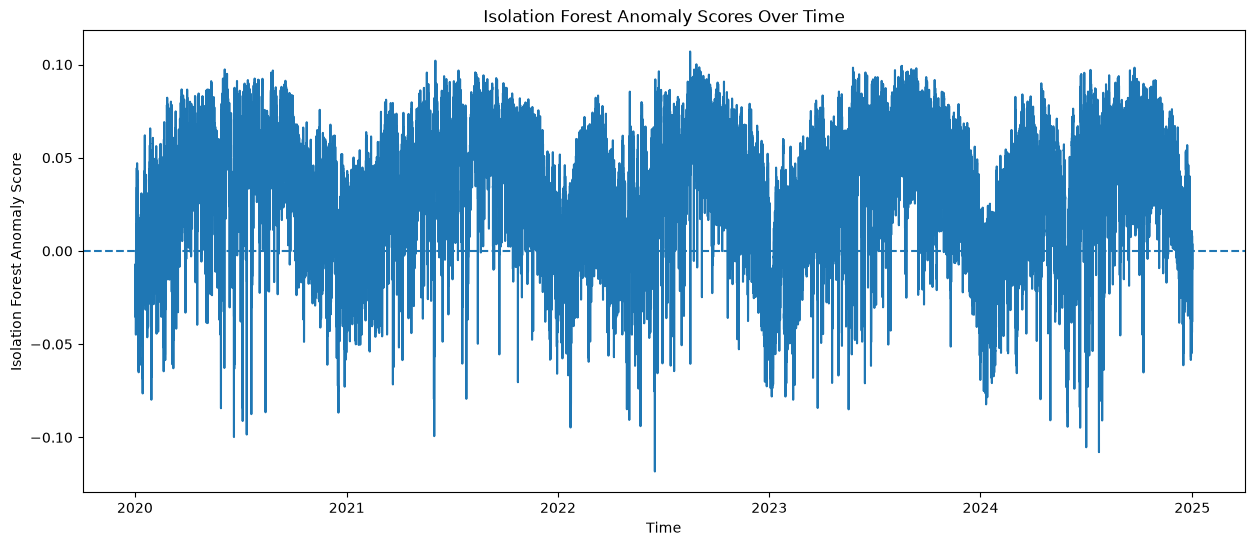

In [103]:
plt.figure(figsize=(15, 6))

plt.plot(
    ml_df["timestamp"],
    ml_df["anomaly_score"]
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Isolation Forest Anomaly Score")
plt.title("Isolation Forest Anomaly Scores Over Time")
plt.show()

In [104]:
comparison = pd.DataFrame({
    "Z-score": df.loc[ml_df.index, "zscore_anomaly"],
    "IQR": df.loc[ml_df.index, "iqr_anomaly"],
    "Isolation Forest": ml_df["isolation_anomaly"]
})

comparison.sum()

Z-score                0
IQR                    0
Isolation Forest    5522
dtype: int64

In [105]:
from sklearn.preprocessing import StandardScaler

autoencoder_features = [
    "temperature",
    "humidity",
    "pressure",
    "hour",
    "month",
    "temperature_change",
    "humidity_change",
    "pressure_change",
    "temperature_rolling_mean",
    "temperature_rolling_std",
    "humidity_rolling_mean",
    "humidity_rolling_std",
    "pressure_rolling_mean",
    "pressure_rolling_std",
    "temperature_deviation",
    "humidity_deviation",
    "pressure_deviation"
]

ae_df = df.dropna(subset=autoencoder_features).copy()

X_ae = ae_df[autoencoder_features]

print("Autoencoder rows:", len(ae_df))
print("Features:", X_ae.shape[1])

Autoencoder rows: 43825
Features: 17


In [106]:
train_size = int(len(X_ae) * 0.7)
val_size = int(len(X_ae) * 0.15)

X_train = X_ae.iloc[:train_size]
X_val = X_ae.iloc[train_size:train_size + val_size]
X_test = X_ae.iloc[train_size + val_size:]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (30677, 17)
Validation: (6573, 17)
Test: (6575, 17)


In [107]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Training mean:", X_train_scaled.mean())
print("Training std:", X_train_scaled.std())

Training mean: 5.510937026211347e-16
Training std: 1.0


In [108]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Train tensor:", X_train_tensor.shape)
print("Validation tensor:", X_val_tensor.shape)

Train tensor: torch.Size([30677, 17])
Validation tensor: torch.Size([6573, 17])


In [109]:
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 12),
            nn.ReLU(),
            nn.Linear(12, 6),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Linear(6, 12),
            nn.ReLU(),
            nn.Linear(12, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


model_ae = Autoencoder(input_dim=X_train_tensor.shape[1])

print(model_ae)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=17, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=6, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=6, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=17, bias=True)
  )
)


In [110]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_ae.parameters(),
    lr=0.001
)

print("Autoencoder ready")

Autoencoder ready


In [111]:
epochs = 30

train_losses = []
val_losses = []

for epoch in range(epochs):

    model_ae.train()
    train_loss = 0.0

    for (batch,) in train_loader:
        optimizer.zero_grad()

        reconstructed = model_ae(batch)
        loss = criterion(reconstructed, batch)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model_ae.eval()
    val_loss = 0.0

    with torch.no_grad():
        for (batch,) in val_loader:
            reconstructed = model_ae(batch)
            loss = criterion(reconstructed, batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{epochs}] "
        f"Train Loss: {train_loss:.6f} "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch [1/30] Train Loss: 0.753302 Val Loss: 0.452479
Epoch [2/30] Train Loss: 0.376969 Val Loss: 0.318802
Epoch [3/30] Train Loss: 0.289219 Val Loss: 0.268661
Epoch [4/30] Train Loss: 0.239912 Val Loss: 0.210974
Epoch [5/30] Train Loss: 0.201983 Val Loss: 0.177446
Epoch [6/30] Train Loss: 0.183110 Val Loss: 0.161738
Epoch [7/30] Train Loss: 0.172422 Val Loss: 0.151954
Epoch [8/30] Train Loss: 0.166739 Val Loss: 0.149595
Epoch [9/30] Train Loss: 0.163837 Val Loss: 0.149715
Epoch [10/30] Train Loss: 0.162114 Val Loss: 0.146526
Epoch [11/30] Train Loss: 0.160484 Val Loss: 0.148601
Epoch [12/30] Train Loss: 0.159252 Val Loss: 0.147086
Epoch [13/30] Train Loss: 0.157884 Val Loss: 0.144591
Epoch [14/30] Train Loss: 0.156779 Val Loss: 0.142999
Epoch [15/30] Train Loss: 0.155700 Val Loss: 0.145659
Epoch [16/30] Train Loss: 0.154609 Val Loss: 0.141294
Epoch [17/30] Train Loss: 0.153655 Val Loss: 0.140556
Epoch [18/30] Train Loss: 0.152699 Val Loss: 0.140744
Epoch [19/30] Train Loss: 0.151921 Va

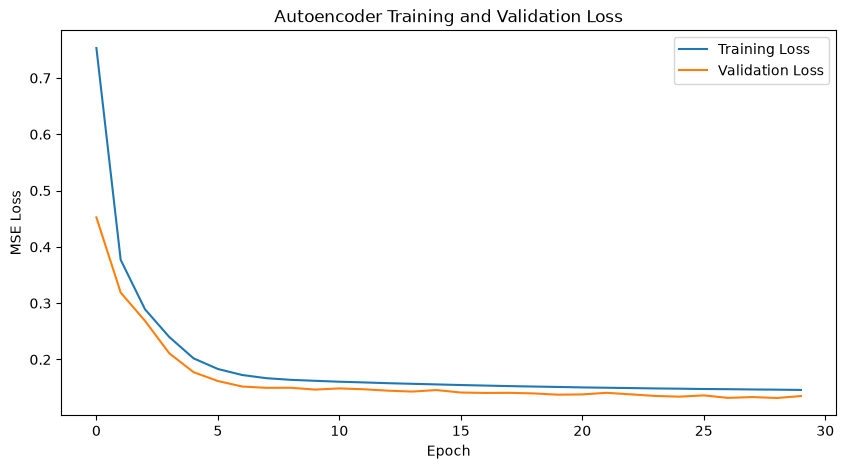

In [112]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training and Validation Loss")
plt.legend()
plt.show()

In [113]:
model_ae.eval()

with torch.no_grad():
    X_test_reconstructed = model_ae(X_test_tensor)

reconstruction_error = torch.mean(
    (X_test_tensor - X_test_reconstructed) ** 2,
    dim=1
).numpy()

print("Reconstruction errors:", len(reconstruction_error))
print("Minimum:", reconstruction_error.min())
print("Maximum:", reconstruction_error.max())
print("Mean:", reconstruction_error.mean())

Reconstruction errors: 6575
Minimum: 0.006218787
Maximum: 1.722325
Mean: 0.14325279


In [114]:
with torch.no_grad():
    X_val_reconstructed = model_ae(X_val_tensor)

val_reconstruction_error = torch.mean(
    (X_val_tensor - X_val_reconstructed) ** 2,
    dim=1
).numpy()

In [115]:
threshold = np.percentile(val_reconstruction_error, 95)

print("Anomaly threshold:", threshold)

Anomaly threshold: 0.33725825


In [116]:
test_anomaly = reconstruction_error > threshold

print("Autoencoder anomalies:", test_anomaly.sum())
print("Total test observations:", len(test_anomaly))

Autoencoder anomalies: 453
Total test observations: 6575


In [117]:
test_anomaly = reconstruction_error > threshold

print("Autoencoder anomalies:", test_anomaly.sum())
print("Total test observations:", len(test_anomaly))
print("Anomaly percentage:", test_anomaly.mean() * 100)

Autoencoder anomalies: 453
Total test observations: 6575
Anomaly percentage: 6.889733840304182


In [118]:
ae_results = ae_df.iloc[
    train_size + val_size:
].copy()

ae_results["reconstruction_error"] = reconstruction_error
ae_results["autoencoder_anomaly"] = test_anomaly

print(ae_results["autoencoder_anomaly"].value_counts())

autoencoder_anomaly
False    6122
True      453
Name: count, dtype: int64


In [119]:
ae_results[
    [
        "timestamp",
        "temperature",
        "humidity",
        "pressure",
        "reconstruction_error"
    ]
].sort_values(
    "reconstruction_error",
    ascending=False
).head(10)

,timestamp,temperature,humidity,pressure,reconstruction_error
39183,2024-06-20 15:00:00,35.5,49,994.3,1.722325
39182,2024-06-20 14:00:00,28.8,72,996.8,1.339121
43308,2024-12-09 12:00:00,19.3,46,1017.3,1.206649
39513,2024-07-04 09:00:00,28.8,83,1000.0,1.176201
41824,2024-10-08 16:00:00,22.7,88,1013.4,1.168098
43309,2024-12-09 13:00:00,20.2,41,1016.6,1.089197
41773,2024-10-06 13:00:00,33.9,39,1010.8,1.060974
39515,2024-07-04 11:00:00,33.9,62,998.9,1.025006
41772,2024-10-06 12:00:00,32.9,43,1012.1,1.023824
41771,2024-10-06 11:00:00,32.1,47,1013.0,1.010355


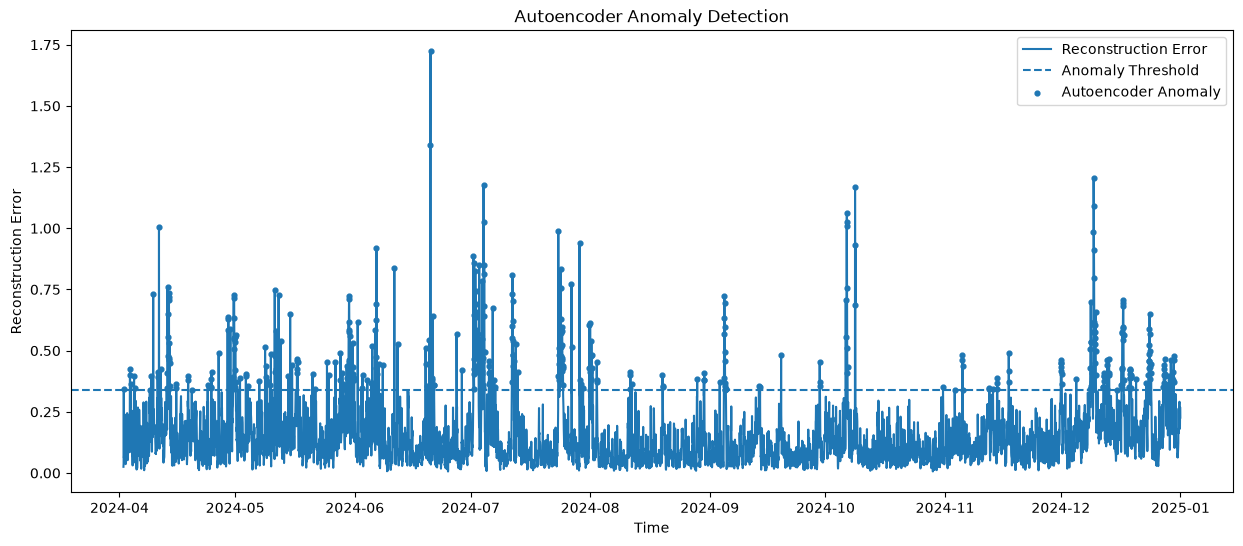

In [120]:
plt.figure(figsize=(15, 6))

plt.plot(
    ae_results["timestamp"],
    ae_results["reconstruction_error"],
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Anomaly Threshold"
)

anomalies = ae_results[ae_results["autoencoder_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["reconstruction_error"],
    label="Autoencoder Anomaly",
    s=12
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("Autoencoder Anomaly Detection")
plt.legend()
plt.show()

In [121]:
print("Autoencoder anomalies:", ae_results["autoencoder_anomaly"].sum())
print(
    "Anomaly percentage:",
    ae_results["autoencoder_anomaly"].mean() * 100
)

Autoencoder anomalies: 453
Anomaly percentage: 6.889733840304182


In [122]:
# Z-score baseline
from scipy.stats import zscore

sensor_cols = ["temperature", "humidity", "pressure"]

z_scores = ml_df[sensor_cols].apply(zscore)

ml_df["zscore_anomaly"] = (z_scores.abs() > 3).any(axis=1)


# IQR baseline
iqr_anomaly = pd.Series(False, index=ml_df.index)

for col in sensor_cols:
    Q1 = ml_df[col].quantile(0.25)
    Q3 = ml_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_anomaly |= (
        (ml_df[col] < lower) |
        (ml_df[col] > upper)
    )

ml_df["iqr_anomaly"] = iqr_anomaly

print("Z-score anomalies:", ml_df["zscore_anomaly"].sum())
print("IQR anomalies:", ml_df["iqr_anomaly"].sum())
print("Isolation Forest anomalies:", ml_df["isolation_anomaly"].sum())

Z-score anomalies: 0
IQR anomalies: 0
Isolation Forest anomalies: 5522


In [123]:
comparison = ml_df[
    [
        "timestamp",
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly"
    ]
].copy()

comparison = comparison.merge(
    ae_results[
        [
            "timestamp",
            "reconstruction_error",
            "autoencoder_anomaly"
        ]
    ],
    on="timestamp",
    how="left"
)

print(comparison.columns.tolist())

['timestamp', 'zscore_anomaly', 'iqr_anomaly', 'isolation_anomaly', 'reconstruction_error', 'autoencoder_anomaly']


In [124]:
print(
    comparison[
        [
            "zscore_anomaly",
            "iqr_anomaly",
            "isolation_anomaly",
            "autoencoder_anomaly"
        ]
    ].sum()
)

zscore_anomaly            0
iqr_anomaly               0
isolation_anomaly      5522
autoencoder_anomaly     453
dtype: object


In [125]:
print(ml_df["zscore_anomaly"].value_counts(dropna=False))
print()
print(ml_df["iqr_anomaly"].value_counts(dropna=False))

zscore_anomaly
False    43825
Name: count, dtype: int64

iqr_anomaly
False    43825
Name: count, dtype: int64


In [126]:
test_comparison = comparison[
    comparison["autoencoder_anomaly"].notna()
].copy()

print("Common comparison observations:", len(test_comparison))

Common comparison observations: 6575


In [127]:
method_counts = test_comparison[
    [
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly",
        "autoencoder_anomaly"
    ]
].sum()

print(method_counts)

zscore_anomaly           0
iqr_anomaly              0
isolation_anomaly      757
autoencoder_anomaly    453
dtype: object


In [128]:
test_comparison["methods_detecting"] = test_comparison[
    [
        "zscore_anomaly",
        "iqr_anomaly",
        "isolation_anomaly",
        "autoencoder_anomaly"
    ]
].sum(axis=1)

print(
    test_comparison["methods_detecting"]
    .value_counts()
    .sort_index()
)

methods_detecting
0    5601
1     738
2     236
Name: count, dtype: int64


In [129]:
ml_overlap = test_comparison[
    (test_comparison["isolation_anomaly"]) &
    (test_comparison["autoencoder_anomaly"])
]

print("Detected by both ML methods:", len(ml_overlap))

Detected by both ML methods: 236


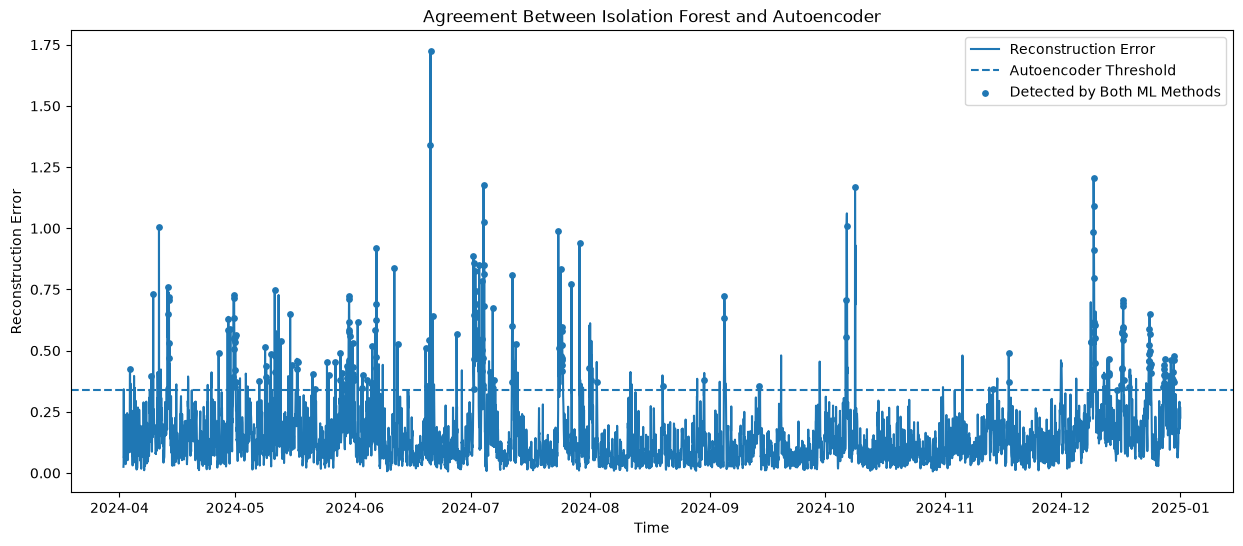

In [130]:
plt.figure(figsize=(15, 6))

plt.plot(
    test_comparison["timestamp"],
    test_comparison["reconstruction_error"],
    label="Reconstruction Error"
)

plt.axhline(
    threshold,
    linestyle="--",
    label="Autoencoder Threshold"
)

plt.scatter(
    ml_overlap["timestamp"],
    ml_overlap["reconstruction_error"],
    s=15,
    label="Detected by Both ML Methods"
)

plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.title("Agreement Between Isolation Forest and Autoencoder")
plt.legend()
plt.show()

In [131]:
scoring_df = test_comparison[                               #common observations for scoring, including the timestamp, anomaly flags from both ML methods, and the reconstruction error from the autoencoder. This will allow us to analyze and compare the performance of the two methods on the same set of observations.
    [
        "timestamp",
        "isolation_anomaly",
        "autoencoder_anomaly",
        "reconstruction_error"
    ]
].copy()

# Add Isolation Forest score
scoring_df = scoring_df.merge(
    ml_df[
        ["timestamp", "anomaly_score"]
    ],
    on="timestamp",
    how="left"
)

print("Scoring observations:", len(scoring_df))
scoring_df.head()

Scoring observations: 6575


,timestamp,isolation_anomaly,autoencoder_anomaly,reconstruction_error,anomaly_score
0,2024-04-02 01:00:00,False,False,0.025391,0.052995
1,2024-04-02 02:00:00,False,False,0.039400,0.030158
2,2024-04-02 03:00:00,False,True,0.342281,0.037530
3,2024-04-02 04:00:00,False,False,0.061759,0.065344
4,2024-04-02 05:00:00,False,False,0.076247,0.072308


In [132]:
scoring_df["isolation_score"] = (                #convert Isolation Forest anomaly scores to percentile ranks. This helps in comparing the severity of anomalies detected by the Isolation Forest model.
    1 - scoring_df["anomaly_score"].rank(pct=True)
)

In [133]:
scoring_df["autoencoder_score"] = (                   # convert reconstruction errors to percentile ranks
    scoring_df["reconstruction_error"].rank(pct=True)
)

In [134]:
scoring_df["combined_anomaly_score"] = (  #create a combined anomaly score by averaging the Isolation Forest and Autoencoder scores. This provides a unified metric for anomaly detection, leveraging the strengths of both methods.
    0.5 * scoring_df["isolation_score"] +
    0.5 * scoring_df["autoencoder_score"]
)

In [135]:
scoring_df["combined_anomaly_score"].describe() #check it

count    6575.000000
mean        0.500000
std         0.253815
min         0.002205
25%         0.296236
50%         0.501901
75%         0.698175
max         0.999087
Name: combined_anomaly_score, dtype: float64

In [136]:
def classify_severity(score):      # create severity levels based on the combined anomaly score, helps in prioritizing anomalies for further investigation or action.
    if score >= 0.90:
        return "High"
    elif score >= 0.75:
        return "Medium"
    else:
        return "Low"


scoring_df["severity"] = (
    scoring_df["combined_anomaly_score"]
    .apply(classify_severity)
)

In [137]:
print(scoring_df["severity"].value_counts())

severity
Low       5286
Medium     840
High       449
Name: count, dtype: int64


In [138]:
top_anomalies = scoring_df.sort_values(           # strongest anomalies based on the combined anomaly score. 
    "combined_anomaly_score",        
    ascending=False
)

top_anomalies[
    [
        "timestamp",
        "isolation_score",
        "autoencoder_score",
        "combined_anomaly_score",
        "severity"
    ]
].head(10)

,timestamp,isolation_score,autoencoder_score,combined_anomaly_score,severity
2705,2024-07-23 18:00:00,0.999848,0.998327,0.999087,High
1909,2024-06-20 14:00:00,0.998327,0.999848,0.999087,High
2837,2024-07-29 06:00:00,0.999240,0.998023,0.998631,High
2177,2024-07-01 18:00:00,0.999696,0.997414,0.998555,High
2240,2024-07-04 09:00:00,0.996654,0.999544,0.998099,High
4551,2024-10-08 16:00:00,0.995285,0.999392,0.997338,High
1685,2024-06-11 06:00:00,0.997110,0.996806,0.996958,High
2787,2024-07-27 04:00:00,0.998023,0.995741,0.996882,High
1404,2024-05-30 13:00:00,0.999392,0.993916,0.996654,High
1403,2024-05-30 12:00:00,0.998783,0.993460,0.996122,High


In [139]:
weather_values = ae_df[               # weather values corresponding to the top anomalies for context. This helps us understand the environmental conditions during the detected anomalies.
    [
        "timestamp",
        "temperature",
        "humidity",
        "pressure"
    ]
].copy()

scoring_df = scoring_df.merge(
    weather_values,
    on="timestamp",
    how="left"
)

print(scoring_df.shape)
scoring_df.head()

(6575, 12)


,timestamp,isolation_anomaly,autoencoder_anomaly,reconstruction_error,anomaly_score,isolation_score,autoencoder_score,combined_anomaly_score,severity,temperature,humidity,pressure
0,2024-04-02 01:00:00,False,False,0.025391,0.052995,0.393156,0.036198,0.214677,Low,17.2,64,1008.3
1,2024-04-02 02:00:00,False,False,0.039400,0.030158,0.664335,0.108897,0.386616,Low,16.2,70,1007.8
2,2024-04-02 03:00:00,False,True,0.342281,0.037530,0.588441,0.933080,0.760760,Medium,18.1,59,1007.4
3,2024-04-02 04:00:00,False,False,0.061759,0.065344,0.201521,0.244715,0.223118,Low,18.1,59,1007.1
4,2024-04-02 05:00:00,False,False,0.076247,0.072308,0.118327,0.335361,0.226844,Low,18.2,58,1007.2


In [140]:
# Add the original anomaly flags keep the statistical methods available in the final dataset too:

baseline_flags = ml_df[
    [
        "timestamp",
        "zscore_anomaly",
        "iqr_anomaly"
    ]
].copy()

scoring_df = scoring_df.merge(
    baseline_flags,
    on="timestamp",
    how="left"
)

In [141]:
# Add a final anomaly flag, we need a simple decision that the future API/dashboard can use.
scoring_df["final_anomaly"] = (
    scoring_df["isolation_anomaly"] |
    scoring_df["autoencoder_anomaly"]
)

In [142]:
print("Final anomalies:", scoring_df["final_anomaly"].sum())
print("Total observations:", len(scoring_df))
print(
    "Final anomaly percentage:",
    scoring_df["final_anomaly"].mean() * 100
)

Final anomalies: 974
Total observations: 6575
Final anomaly percentage: 14.813688212927756


In [143]:
# inspect the top anomalies based on the combined anomaly score and their corresponding weather values.
final_columns = [
    "timestamp",
    "temperature",
    "humidity",
    "pressure",
    "isolation_score",
    "autoencoder_score",
    "combined_anomaly_score",
    "severity",
    "final_anomaly"
]

scoring_df[
    final_columns
].sort_values(
    "combined_anomaly_score",
    ascending=False
).head(20)

,timestamp,temperature,humidity,pressure,isolation_score,autoencoder_score,combined_anomaly_score,severity,final_anomaly
2705,2024-07-23 18:00:00,28.8,87,994.6,0.999848,0.998327,0.999087,High,True
1909,2024-06-20 14:00:00,28.8,72,996.8,0.998327,0.999848,0.999087,High,True
2837,2024-07-29 06:00:00,27.8,94,999.2,0.999240,0.998023,0.998631,High,True
2177,2024-07-01 18:00:00,29.9,82,991.9,0.999696,0.997414,0.998555,High,True
2240,2024-07-04 09:00:00,28.8,83,1000.0,0.996654,0.999544,0.998099,High,True
4551,2024-10-08 16:00:00,22.7,88,1013.4,0.995285,0.999392,0.997338,High,True
1685,2024-06-11 06:00:00,28.2,56,1000.9,0.997110,0.996806,0.996958,High,True
2787,2024-07-27 04:00:00,27.7,90,996.2,0.998023,0.995741,0.996882,High,True
1404,2024-05-30 13:00:00,45.7,7,996.3,0.999392,0.993916,0.996654,High,True
1403,2024-05-30 12:00:00,44.7,8,997.2,0.998783,0.993460,0.996122,High,True


In [144]:
# save the final scoring dataframe to a CSV file for further analysis or reporting.
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

In [145]:
output_path = processed_dir / "weather_anomaly_scores.csv"

scoring_df.to_csv(
    output_path,
    index=False
)

print("Saved to:", output_path.resolve())

Saved to: C:\Users\Sreoshi\anomaly-detection\data\processed\weather_anomaly_scores.csv


In [146]:
# Top anomalies according to the unified score
top_anomalies = (
    scoring_df[
        [
            "timestamp",
            "temperature",
            "humidity",
            "pressure",
            "isolation_score",
            "autoencoder_score",
            "combined_anomaly_score",
            "severity",
            "final_anomaly"
        ]
    ]
    .sort_values("combined_anomaly_score", ascending=False)
    .head(20)
)

top_anomalies

,timestamp,temperature,humidity,pressure,isolation_score,autoencoder_score,combined_anomaly_score,severity,final_anomaly
2705,2024-07-23 18:00:00,28.8,87,994.6,0.999848,0.998327,0.999087,High,True
1909,2024-06-20 14:00:00,28.8,72,996.8,0.998327,0.999848,0.999087,High,True
2837,2024-07-29 06:00:00,27.8,94,999.2,0.999240,0.998023,0.998631,High,True
2177,2024-07-01 18:00:00,29.9,82,991.9,0.999696,0.997414,0.998555,High,True
2240,2024-07-04 09:00:00,28.8,83,1000.0,0.996654,0.999544,0.998099,High,True
4551,2024-10-08 16:00:00,22.7,88,1013.4,0.995285,0.999392,0.997338,High,True
1685,2024-06-11 06:00:00,28.2,56,1000.9,0.997110,0.996806,0.996958,High,True
2787,2024-07-27 04:00:00,27.7,90,996.2,0.998023,0.995741,0.996882,High,True
1404,2024-05-30 13:00:00,45.7,7,996.3,0.999392,0.993916,0.996654,High,True
1403,2024-05-30 12:00:00,44.7,8,997.2,0.998783,0.993460,0.996122,High,True


In [147]:
# How many anomalies fall into each severity level?
scoring_df["severity"].value_counts()

severity
Low       5286
Medium     840
High       449
Name: count, dtype: int64

In [148]:
# Agreement between the two ML models
pd.crosstab(
    scoring_df["isolation_anomaly"],
    scoring_df["autoencoder_anomaly"],
    rownames=["Isolation Forest"],
    colnames=["Autoencoder"]
)

Autoencoder,False,True
Isolation Forest,,
False,5601,217
True,521,236


In [149]:
# Anomalies grouped by month
monthly_anomalies = (
    scoring_df[scoring_df["final_anomaly"]]
    .assign(month=lambda x: x["timestamp"].dt.to_period("M"))
    .groupby("month")
    .size()
    .sort_values(ascending=False)
)

monthly_anomalies.head(15)

month
2024-12    298
2024-05    259
2024-07    138
2024-06     96
2024-04     84
2024-08     37
2024-09     23
2024-11     23
2024-10     16
Freq: M, dtype: int64

In [150]:
anomaly_times = (                                # Check consecutive anomaly points
    scoring_df[scoring_df["final_anomaly"]]["timestamp"]
    .sort_values()
)

time_gaps = anomaly_times.diff().value_counts().head(10)

time_gaps

timestamp
0 days 01:00:00    710
0 days 02:00:00     43
0 days 03:00:00     33
0 days 04:00:00     15
0 days 06:00:00     15
0 days 12:00:00     13
0 days 07:00:00     11
0 days 21:00:00      9
0 days 11:00:00      9
0 days 09:00:00      8
Name: count, dtype: int64

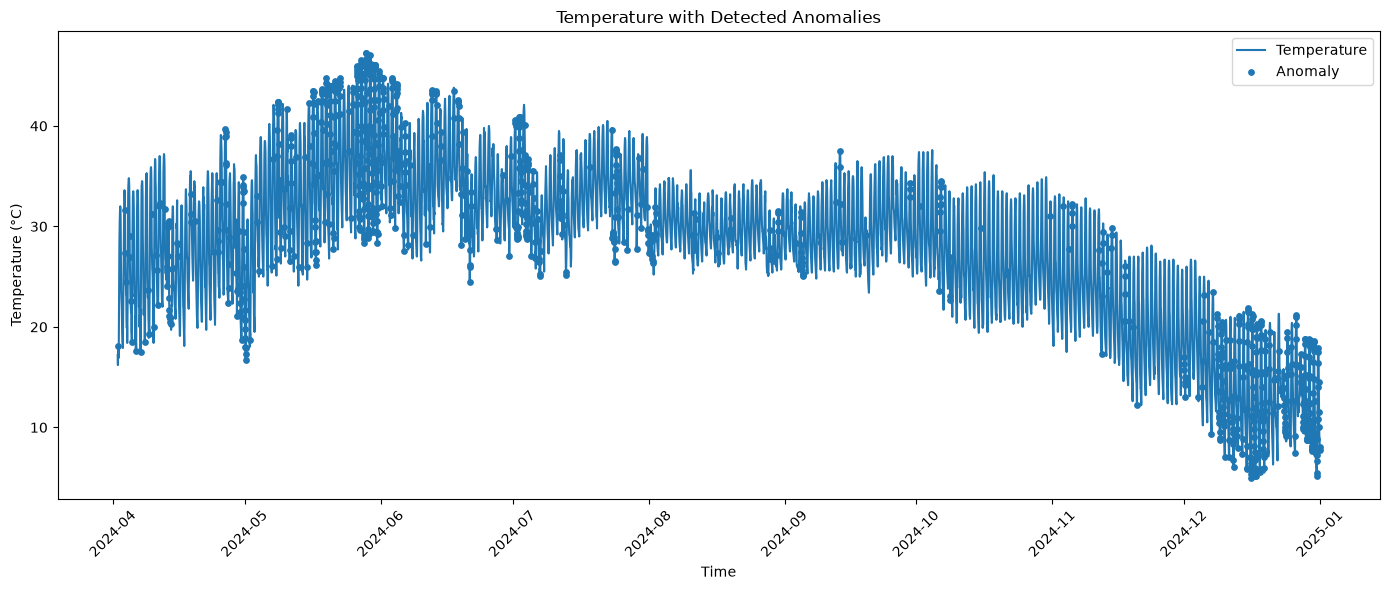

In [151]:
# visualize the distribution of time gaps between consecutive anomalies to understand their frequency and clustering behavior.
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    scoring_df["timestamp"],
    scoring_df["temperature"],
    label="Temperature"
)

anomalies = scoring_df[scoring_df["final_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["temperature"],
    label="Anomaly",
    s=15
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Temperature with Detected Anomalies")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

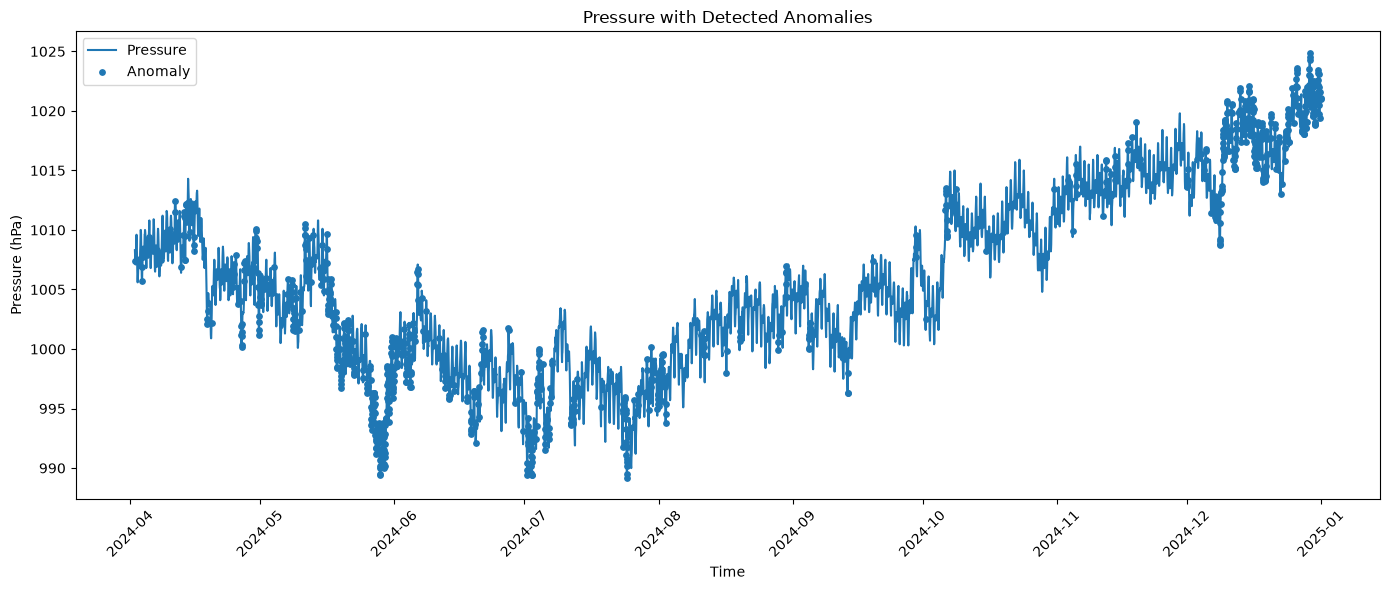

In [152]:
plt.figure(figsize=(14, 6))      #add pressure plot to visualize anomalies in pressure readings over time, similar to the temperature plot above. 

plt.plot(
    scoring_df["timestamp"],
    scoring_df["pressure"],
    label="Pressure")

plt.scatter(
    anomalies["timestamp"],
    anomalies["pressure"],
    label="Anomaly",
    s=15)

plt.xlabel("Time")
plt.ylabel("Pressure (hPa)")
plt.title("Pressure with Detected Anomalies")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [153]:
# Count the four possible combinations
agreement = pd.crosstab(
    scoring_df["isolation_anomaly"],
    scoring_df["autoencoder_anomaly"]
)

agreement

autoencoder_anomaly,False,True
isolation_anomaly,,
False,5601,217
True,521,236


In [154]:
both_anomalies = (                                 #calculate the number of anomalies detected by both models and the number detected by either model, then computing the agreement percentage between the two models.
    scoring_df["isolation_anomaly"] &
    scoring_df["autoencoder_anomaly"]
).sum()

either_anomaly = (
    scoring_df["isolation_anomaly"] |
    scoring_df["autoencoder_anomaly"]
).sum()

agreement_percentage = (
    both_anomalies / either_anomaly * 100
)

print("Detected by both models:", both_anomalies)
print("Detected by either model:", either_anomaly)
print("Agreement percentage:", round(agreement_percentage, 2), "%")

Detected by both models: 236
Detected by either model: 974
Agreement percentage: 24.23 %


In [155]:
#Check anomaly severity distribution Now see whether our unified score is producing a reasonable spread of low/medium/high anomalies.

severity_counts = scoring_df["severity"].value_counts()
severity_counts

severity
Low       5286
Medium     840
High       449
Name: count, dtype: int64

In [156]:
severity_percent = (
    scoring_df["severity"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

severity_percent

severity
Low       80.40
Medium    12.78
High       6.83
Name: proportion, dtype: float64

In [157]:
scoring_df.groupby("severity")["combined_anomaly_score"].agg(          #actual score ranges
    ["count", "min", "max", "mean"]
)

,count,min,max,mean
severity,,,,
High,449,0.900076,0.999087,0.942831
Low,5286,0.002205,0.749886,0.411331
Medium,840,0.750114,0.899772,0.821279


In [158]:
evaluation_summary = {
    "total_test_observations": len(scoring_df),                                            # evaluation summary
    "isolation_forest_anomalies": int(scoring_df["isolation_anomaly"].sum()),
    "autoencoder_anomalies": int(scoring_df["autoencoder_anomaly"].sum()),
    "final_anomalies": int(scoring_df["final_anomaly"].sum()),
    "high_severity": int((scoring_df["severity"] == "High").sum()),
    "medium_severity": int((scoring_df["severity"] == "Medium").sum()),
    "low_severity": int((scoring_df["severity"] == "Low").sum()),
    "detected_by_both_models": int(
        (
            scoring_df["isolation_anomaly"]
            & scoring_df["autoencoder_anomaly"]
        ).sum()
    )
}

evaluation_summary

{'total_test_observations': 6575,
 'isolation_forest_anomalies': 757,
 'autoencoder_anomalies': 453,
 'final_anomalies': 974,
 'high_severity': 449,
 'medium_severity': 840,
 'low_severity': 5286,
 'detected_by_both_models': 236}

In [159]:
evaluation_df = pd.DataFrame(
    evaluation_summary.items(),
    columns=["metric", "value"]
)

evaluation_df

,metric,value
0,total_test_observations,6575
1,isolation_forest_anomalies,757
2,autoencoder_anomalies,453
3,final_anomalies,974
4,high_severity,449
5,medium_severity,840
6,low_severity,5286
7,detected_by_both_models,236


In [160]:
import sys
print("Python:", sys.executable)

import pandas as pd
print("Pandas:", pd.__version__)

import scipy
print("SciPy:", scipy.__version__)

import sklearn
print("Scikit-learn:", sklearn.__version__)

import torch
print("PyTorch:", torch.__version__)

Python: c:\Users\Sreoshi\anomaly-detection\.venv\Scripts\python.exe
Pandas: 3.0.6
SciPy: 1.18.1
Scikit-learn: 1.9.1
PyTorch: 2.14.0+cpu


In [161]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
print("Current directory:", Path.cwd())
print("Project root:", project_root)
print("src folder exists:", (project_root / "src").is_dir())

sys.path.insert(0, str(project_root))

Current directory: c:\Users\Sreoshi\anomaly-detection\notebooks
Project root: c:\Users\Sreoshi\anomaly-detection
src folder exists: True


In [162]:
from src.pipeline import run_pipeline

print("Pipeline import successful!")

Pipeline import successful!


In [163]:
from src.pipeline import run_pipeline

results, autoencoder, isolation_model, scaler, threshold = run_pipeline(
    "../data/raw/abohar_weather.csv",
    epochs=30
)

print("Pipeline completed successfully!")
print("Results shape:", results.shape)
print("Validation threshold:", threshold)
print("\nAnomaly counts:")
print(results["final_anomaly"].value_counts())
print("\nSeverity distribution:")
print(results["severity"].value_counts())
print("\nSample results:")
display(results.head())

Pipeline completed successfully!
Results shape: (6574, 13)
Validation threshold: 0.31835582852363586

Anomaly counts:
final_anomaly
False    5592
True      982
Name: count, dtype: int64

Severity distribution:
severity
Low       5355
Medium     820
High       399
Name: count, dtype: int64

Sample results:


,timestamp,temperature,humidity,pressure,isolation_anomaly,autoencoder_anomaly,anomaly_score,reconstruction_error,isolation_score,autoencoder_score,combined_anomaly_score,severity,final_anomaly
37251,2024-04-02 02:00:00,16.2,70,1007.8,False,False,0.052592,0.057915,0.429875,0.296015,0.362945,Low,False
37252,2024-04-02 03:00:00,18.1,59,1007.4,False,False,0.052708,0.238380,0.427137,0.893064,0.660100,Low,False
37253,2024-04-02 04:00:00,18.1,59,1007.1,False,False,0.086116,0.094956,0.041375,0.522665,0.282020,Low,False
37254,2024-04-02 05:00:00,18.2,58,1007.2,False,False,0.092791,0.114076,0.011865,0.615759,0.313812,Low,False
37255,2024-04-02 06:00:00,16.9,69,1008.1,False,False,0.038227,0.136881,0.603438,0.699878,0.651658,Low,False


In [166]:
from pathlib import Path

output_path = Path("../data/processed/weather_anomaly_scores.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

results.to_csv(output_path, index=False)

print("Results saved to:", output_path.resolve())
print("Rows saved:", len(results))
print("Columns:", results.columns.tolist())

Results saved to: C:\Users\Sreoshi\anomaly-detection\data\processed\weather_anomaly_scores.csv
Rows saved: 6574
Columns: ['timestamp', 'temperature', 'humidity', 'pressure', 'isolation_anomaly', 'autoencoder_anomaly', 'anomaly_score', 'reconstruction_error', 'isolation_score', 'autoencoder_score', 'combined_anomaly_score', 'severity', 'final_anomaly']


In [167]:
print("Total rows:", len(results))
print("Total anomalies:", results["final_anomaly"].sum())
print("Normal observations:", (~results["final_anomaly"]).sum())

print("\nSeverity distribution:")
print(results["severity"].value_counts())

print("\nMissing values:")
print(results.isnull().sum())

print("\nSample results:")
display(results.head(10))

Total rows: 6574
Total anomalies: 982
Normal observations: 5592

Severity distribution:
severity
Low       5355
Medium     820
High       399
Name: count, dtype: int64

Missing values:
timestamp                 0
temperature               0
humidity                  0
pressure                  0
isolation_anomaly         0
autoencoder_anomaly       0
anomaly_score             0
reconstruction_error      0
isolation_score           0
autoencoder_score         0
combined_anomaly_score    0
severity                  0
final_anomaly             0
dtype: int64

Sample results:


,timestamp,temperature,humidity,pressure,isolation_anomaly,autoencoder_anomaly,anomaly_score,reconstruction_error,isolation_score,autoencoder_score,combined_anomaly_score,severity,final_anomaly
37251,2024-04-02 02:00:00,16.2,70,1007.8,False,False,0.052592,0.057915,0.429875,0.296015,0.362945,Low,False
37252,2024-04-02 03:00:00,18.1,59,1007.4,False,False,0.052708,0.238380,0.427137,0.893064,0.660100,Low,False
37253,2024-04-02 04:00:00,18.1,59,1007.1,False,False,0.086116,0.094956,0.041375,0.522665,0.282020,Low,False
37254,2024-04-02 05:00:00,18.2,58,1007.2,False,False,0.092791,0.114076,0.011865,0.615759,0.313812,Low,False
37255,2024-04-02 06:00:00,16.9,69,1008.1,False,False,0.038227,0.136881,0.603438,0.699878,0.651658,Low,False
37256,2024-04-02 07:00:00,18.7,63,1008.4,False,False,0.088923,0.091906,0.026620,0.505020,0.265820,Low,False
37257,2024-04-02 08:00:00,22.5,53,1009.1,False,False,0.061764,0.096590,0.313204,0.530727,0.421965,Low,False
37258,2024-04-02 09:00:00,26.1,39,1009.4,False,False,0.045527,0.082199,0.519623,0.453757,0.486690,Low,False
37259,2024-04-02 10:00:00,28.1,33,1009.6,False,False,0.080174,0.117850,0.084119,0.630818,0.357469,Low,False
37260,2024-04-02 11:00:00,29.5,29,1009.0,False,False,0.067516,0.093666,0.230605,0.515211,0.372908,Low,False


In [ ]:
# Pipeline Output Validation

print("Total rows:", len(results))

print("\nMissing combined scores:")
print(results["combined_anomaly_score"].isna().sum())

print("\nMissing severity labels:")
print(results["severity"].isna().sum())

print("\nSeverity counts, including missing values:")
print(results["severity"].value_counts(dropna=False))

print("\nScore summary:")
print(results["combined_anomaly_score"].describe())

Total rows: 6574

Missing combined scores:
0

Missing severity labels:
0

Severity counts, including missing values:
severity
Low       5355
Medium     820
High       399
Name: count, dtype: int64

Score summary:
count    6574.000000
mean        0.500000
std         0.245102
min         0.003575
25%         0.305750
50%         0.493117
75%         0.690904
max         0.999468
Name: combined_anomaly_score, dtype: float64
